# EXPLORATORY DATA ANALYSIS AND LEAD SCORING MODEL
#### Enpal Heat Pump Conversion Lead Prediction
Dataset: 10,000 customer inquiries

Goal: Understanding patterns driving heat pump purchases in Germany and predicting customer conversion

## Step 0: Setup and Import

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (confusion_matrix, 
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance



import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [55]:
#plot settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

## Step 1: Data preprocessing and analysis

### Analysis based Utility functions

In [56]:
def load_conversion_df(df, category_col, target_col='converted'):
    """
    Groups data by category and calculates conversions, leads, and conversion rate.
    """
    dist_df = df.groupby(category_col)[target_col].agg(['sum', 'count', 'mean'])
    
    dist_df['mean'] = dist_df['mean'] * 100
    dist_df.columns = ['Conversions', 'Leads', 'Conv_Rate']
    
    return dist_df.sort_values('Conv_Rate', ascending=False)

def plot_categorical_conversion(dist_df, category_name, avg_rate, plot_dir="plots"):
    """
    Creates a horizontal bar chart and saves it.
    """
    plot_data = dist_df.sort_values('Conv_Rate', ascending=True)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ['#2ECC71' if x > avg_rate else '#E74C3C' for x in plot_data['Conv_Rate']]
    
    bars = ax.barh(range(len(plot_data)), plot_data['Conv_Rate'], 
                   color=colors, alpha=0.7, edgecolor='black')
    
    # Labels and Titles
    ax.set_yticks(range(len(plot_data)))
    ax.set_yticklabels(plot_data.index, fontsize=11)
    ax.set_xlabel('Conversion Rate (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'Conversion Rate by {category_name}', fontsize=15, fontweight='bold', pad=20)
    
    ax.axvline(x=avg_rate, color='black', linestyle='--', linewidth=2, alpha=0.5, 
               label=f'Overall Avg ({avg_rate:.1f}%)')
    
    for bar, rate in zip(bars, plot_data['Conv_Rate']):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, 
                f'{rate:.2f}%', va='center', fontsize=10, fontweight='bold')
    
    ax.legend()
    plt.tight_layout()
    
    # Save
    name = category_name.lower().replace(" ", "_")
    filename = f"{plot_dir}/dist_{name}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    
    plt.show()
    plt.close()
    print(f"Saved: {filename}")

def plot_dual_axis_trend(df, vol_col='count', rate_col='mean', title='Lead Volume and Conversion Rate', save_path=None):
    """
    Creates a dual-axis line chart for volume/count (left) and conversion rate (right).
    
    Parameters:
    - df: The DataFrame (expects time/categories in the index)
    - vol_col: Column name for the volume/count
    - rate_col: Column name for the rate/percentage
    - title: Title of the chart
    - save_path: If provided, saves the figure to this path
    """
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    color_vol = "#EE170B"
    ax1.set_xlabel('Timeline', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Lead Volume (Count)', color=color_vol, fontsize=11, fontweight='bold')
    line1 = ax1.plot(df.index, df[vol_col], color=color_vol, linewidth=2.5, label="Volume", marker='o', markersize=4)
    ax1.tick_params(axis='y', labelcolor=color_vol)
    ax1.grid(True, alpha=0.2)

    ax2 = ax1.twinx() 
    color_rate = '#27AE60' 
    ax2.set_ylabel('Conversion Rate (%)', color=color_rate, fontsize=11, fontweight='bold')
    line2 = ax2.plot(df.index, df[rate_col], color=color_rate, linewidth=2.5, label="Conv. Rate", marker='s', markersize=4)
    ax2.tick_params(axis='y', labelcolor=color_rate)

    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', frameon=True)

    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    fig.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
        
    plt.show()
    plt.close()

def plot_numerical_distribution(df, col_name, title_name, target_col='converted', bins=40, is_currency=False, plot_dir="plots"):
    """
    Creates a dual-histogram to compare distributions of a numerical variable 
    based on conversion.
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Split data
    df_not_conv = df[df[target_col] == 0][col_name].dropna()
    df_conv = df[df[target_col] == 1][col_name].dropna()
    
    # Plotting Histograms
    ax.hist([df_not_conv, df_conv], bins=bins, label=['Not Converted', 'Converted'], 
            color=['#E74C3C', '#2ECC71'], alpha=0.6, edgecolor='black', density=False)
    
    # Formatting Labels
    unit = " (EUR)" if is_currency else ""
    ax.set_xlabel(f'{title_name}{unit}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax.set_title(f'{title_name} Distribution by Conversion', fontsize=15, fontweight='bold', pad=20)
    
    # Adding Median Lines
    med_not = df_not_conv.median()
    med_conv = df_conv.median()
    
    prefix = "€" if is_currency else ""
    suffix = "" if not is_currency else ""
    
    ax.axvline(med_not, color='#C0392B', linestyle='--', linewidth=2, 
               label=f'Not Conv Median: {prefix}{med_not:,.0f}{suffix}')
    ax.axvline(med_conv, color='#27AE60', linestyle='--', linewidth=2, 
               label=f'Converted Median: {prefix}{med_conv:,.0f}{suffix}')
    
    # Currency Formatter, e.g., 50000 to €50K
    if is_currency:
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x/1000:.0f}K'))
    
    ax.legend()
    plt.tight_layout()
    
    name = col_name.lower().replace(" ", "_")
    filename = f"{plot_dir}/dist_num_{name}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    
    plt.show()
    plt.close()
    print(f"Saved: {filename}")


### DATA LOADING AND INITIAL INSPECTION

In [57]:
csv_path = 'dataset/heat_pump_conversion_dataset.csv'
plot_dir = "plots"
df = pd.read_csv(
    csv_path,
    na_values=["", " ", "NA", "N/A", "null", "None"]
)

print("Dataframe shape:", df.shape)
print("Dataframe data types:", df.dtypes)
print("Dataframe statistics:", df.describe())

Dataframe shape: (10000, 13)
Dataframe data types: inquiry_date               object
house_age                  object
heating_system             object
house_size_sqm            float64
num_rooms                   int64
household_income          float64
postal_region              object
marketing_channel          object
contact_attempts            int64
property_value            float64
day_of_week                object
energy_consumption_kwh    float64
converted                   int64
dtype: object
Dataframe statistics:        house_size_sqm     num_rooms  household_income  contact_attempts  \
count    10000.000000  10000.000000      10000.000000       10000.00000   
mean       150.311300      5.464000      64358.510000           3.50600   
std         39.739206      1.708741      26103.318791           1.80463   
min         60.000000      2.000000      30000.000000           1.00000   
25%        123.000000      4.000000      45500.000000           2.00000   
50%        150.000000

In [58]:
df.head()

,inquiry_date,house_age,heating_system,house_size_sqm,num_rooms,household_income,postal_region,marketing_channel,contact_attempts,property_value,day_of_week,energy_consumption_kwh,converted
0,2023-04-15,10-30 years,Gas,96.0,4,59600.0,NW,Referral,4,235000.0,Sat,14027.0,0
1,2023-11-21,10-30 years,Oil,157.0,6,30000.0,BE,Display,5,315000.0,Wed,13991.0,0
2,2023-06-23,<10 years,Oil,151.0,5,49000.0,NW,Organic,3,441000.0,Sun,21844.0,0
3,2024-06-21,10-30 years,Oil,242.0,8,99500.0,BY,Paid Social,4,574000.0,Thu,17041.0,0
4,2024-02-03,10-30 years,Gas,177.0,7,89600.0,NW,Organic,5,361000.0,Tue,NaN,0


In [59]:
# Target sanity
df["converted"] = df["converted"].astype(int)
# Calculating global average
conversion_rate = df["converted"].mean() * 100  # %

print(f"base rate of conversion in the dataset: {conversion_rate}%")

base rate of conversion in the dataset: 5.0%


The target class has Severe class imbalance. Out of 10000 data points, only 500 is converted. A naïve approach with accuracy predicts 0 for everyone and model achieves 95% accuracy, so accuracy is not a deciding metric here.

In [60]:
#numerical features summary
numerical_cols = df.select_dtypes(include=[np.number]).columns.drop('converted')
print(df[numerical_cols].describe().round(2))

       house_size_sqm  num_rooms  household_income  contact_attempts  \
count        10000.00   10000.00          10000.00          10000.00   
mean           150.31       5.46          64358.51              3.51   
std             39.74       1.71          26103.32              1.80   
min             60.00       2.00          30000.00              1.00   
25%            123.00       4.00          45500.00              2.00   
50%            150.00       6.00          59450.00              3.00   
75%            177.00       7.00          77200.00              5.00   
max            293.00       8.00         200000.00             10.00   

       property_value  energy_consumption_kwh  
count        10000.00                 8108.00  
mean        375279.30                15074.08  
std         111132.47                 4903.45  
min          13000.00                 5000.00  
25%         300000.00                11624.25  
50%         375000.00                15166.50  
75%         450

In [61]:
# Missing values
missing = df.isna().sum().sort_values(ascending=False)
display(missing.to_frame("missing_rate"))

missing_by_conv = df.groupby("converted")["energy_consumption_kwh"].apply(lambda s: s.isna().sum())
total_by_conv   = df.groupby("converted")["energy_consumption_kwh"].size()

summary = pd.DataFrame({
    "missing_count": missing_by_conv,
    "total": total_by_conv,
    "missing_rate": (missing_by_conv / total_by_conv * 100)
})
display(summary)

,missing_rate
energy_consumption_kwh,1892
house_age,0
heating_system,0
house_size_sqm,0
inquiry_date,0
num_rooms,0
household_income,0
marketing_channel,0
postal_region,0
contact_attempts,0


,missing_count,total,missing_rate
converted,,,
0,1858,9500,19.557895
1,34,500,6.800000


Only energy_consumption_kwh has missing values, for 1,892 / 10,000 rows (~19%); all other columns have 0 missing.

This missing rate is not uniform across the target:

- For non-converted leads we have ~19.6% missing.

- Whereas, for converted leads only 6.8% missing.

Interpretation from data: Leads that convert are much more likely to have energy consumption recorded. This suggests the missing information might be informative and may reflect data completeness / customer engagement. 

Only missing values exists in 'energy_consumption_kwh' column. 

### Handling inquiry_date and temporal analysis

Saved: plots/weekly_volume_dist.png


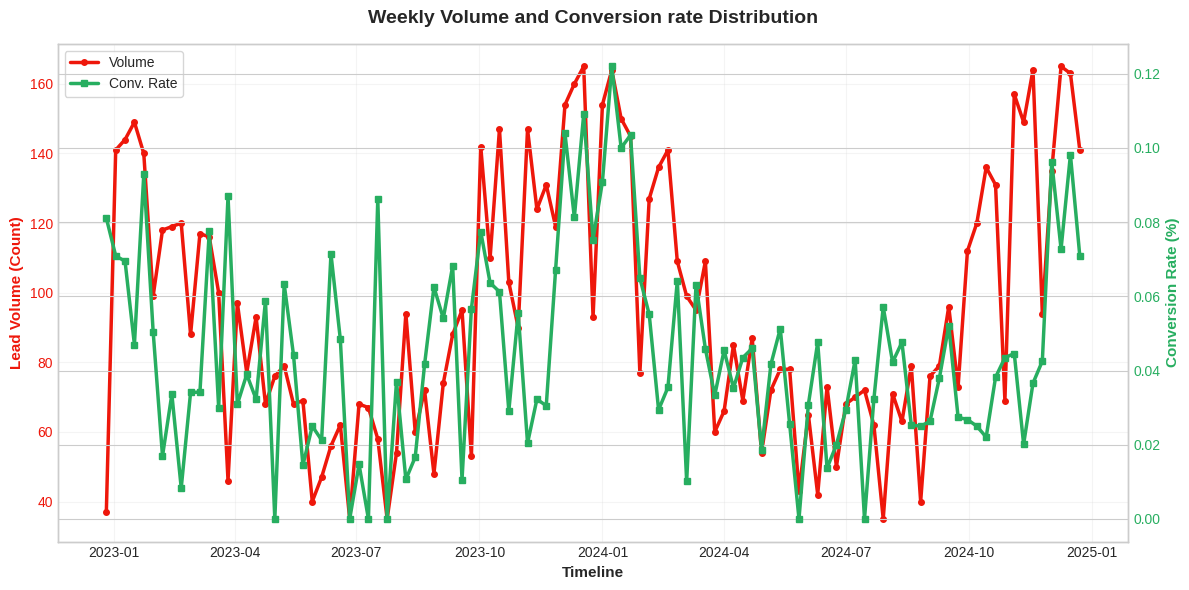

Saved: plots/monthly_volume_dist.png


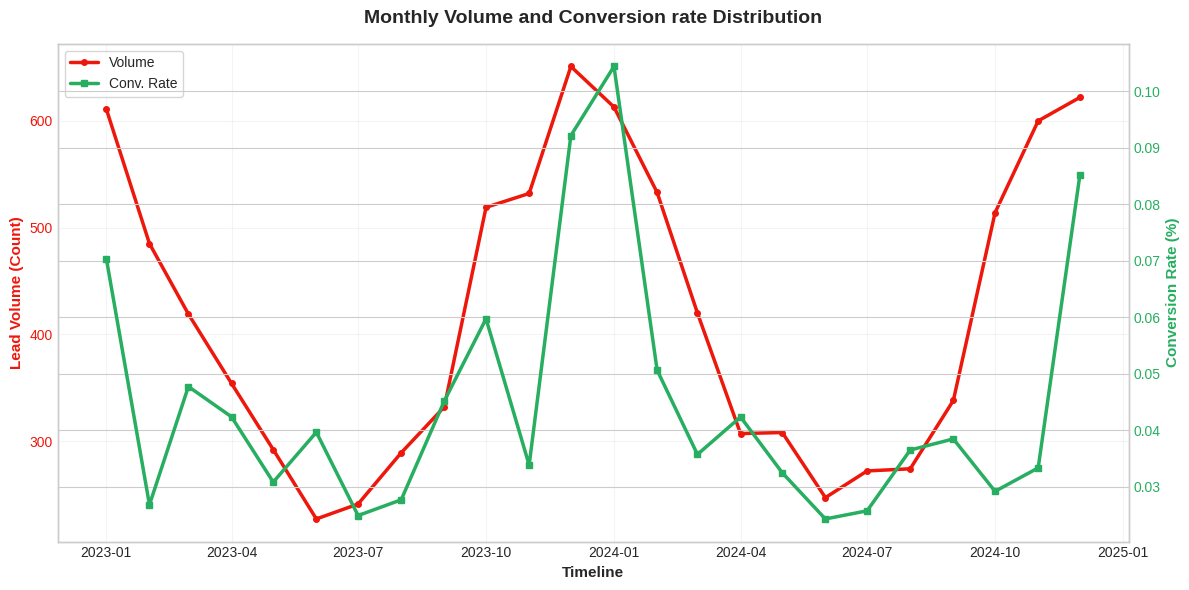

Saved: plots/quarterly_volume_dist.png


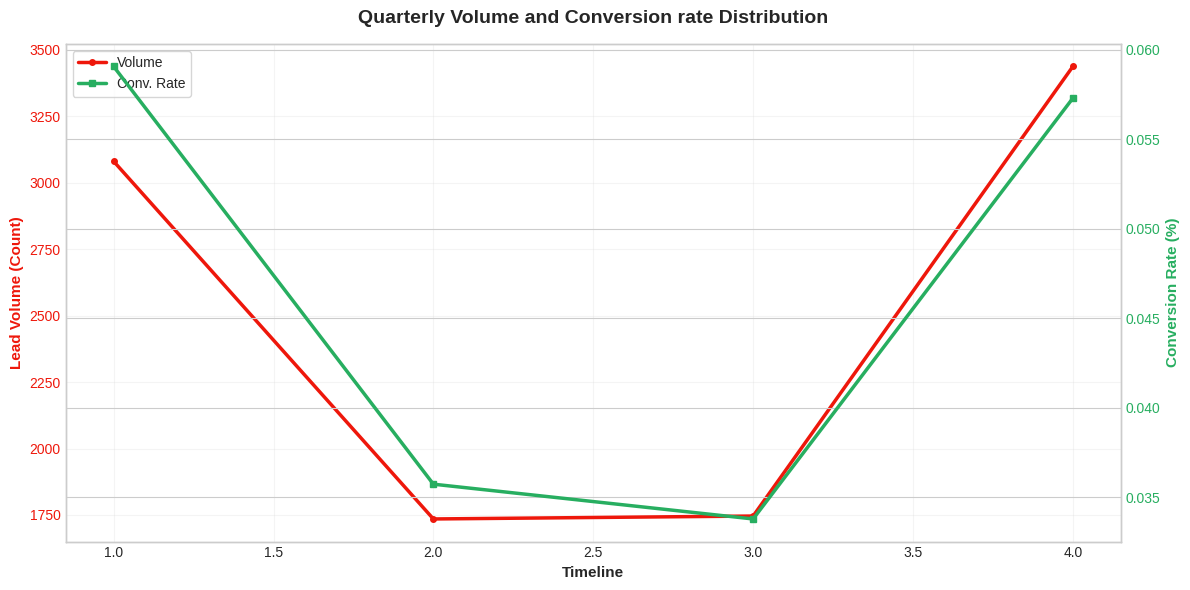

In [62]:
df['inquiry_date'] = pd.to_datetime(df['inquiry_date'])

tmp = df.dropna(subset=["inquiry_date"]).copy()
tmp["week"] = tmp["inquiry_date"].dt.to_period("W").dt.start_time
tmp["month"] = tmp["inquiry_date"].dt.to_period("M").dt.start_time
tmp["quarter"] = tmp["inquiry_date"].dt.quarter

weekly = tmp.groupby("week")["converted"].agg(["mean","count"])
monthly = tmp.groupby("month")["converted"].agg(["mean","count"])
quarterly = tmp.groupby("quarter")["converted"].agg(["mean","count"])

# Plotting weekly wise data
plot_dual_axis_trend(weekly, vol_col='count', rate_col='mean', title="Weekly Volume and Conversion rate Distribution", save_path=f'{plot_dir}/weekly_volume_dist.png')
# Plotting month wise data
plot_dual_axis_trend(monthly, title="Monthly Volume and Conversion rate Distribution", save_path=f'{plot_dir}/monthly_volume_dist.png')
# Plotting quarterly data
plot_dual_axis_trend(quarterly, title="Quarterly Volume and Conversion rate Distribution", save_path=f'{plot_dir}/quarterly_volume_dist.png')


Conversion and lead volume/count show clear seasonal effects: Q1/Q4(winter) perform better than Q2/Q3(hotter weather), so time-aware validation and time features are necessary to model real-world performance.

### Analysing Property Characteristics

             Conversions  Leads  Conv_Rate
house_age                                 
>30 years            213   3094       6.88
10-30 years          215   4959       4.34
<10 years             72   1947       3.70


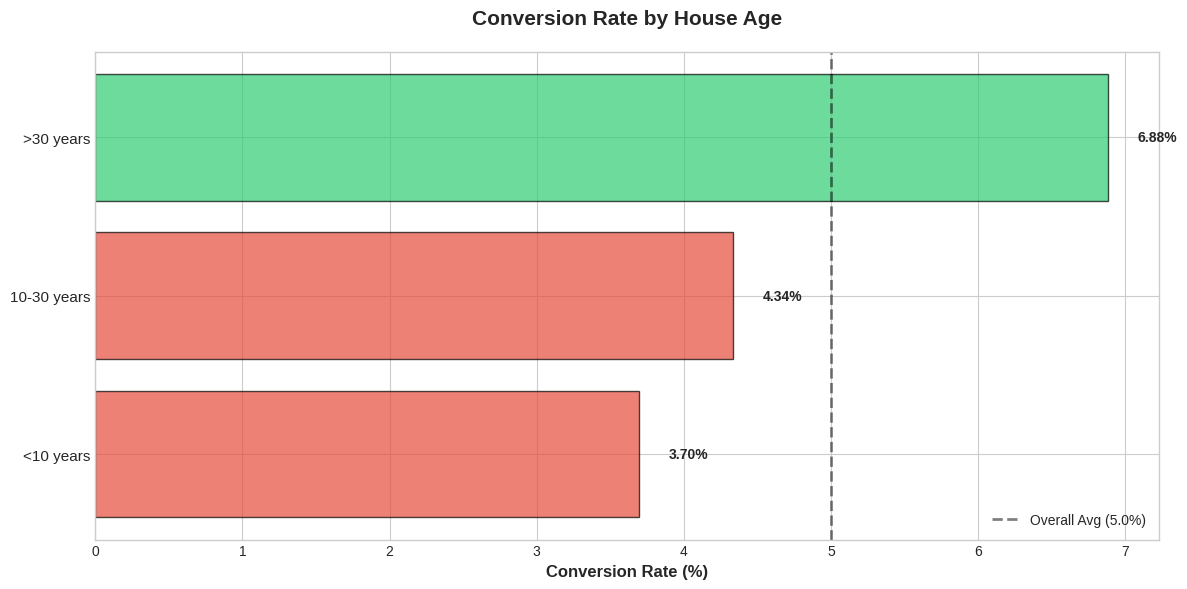

Saved: plots/dist_house_age.png


In [63]:
# House Age
house_age_stats = load_conversion_df(df, 'house_age')
print(house_age_stats.round(2))
plot_categorical_conversion(house_age_stats, 'House Age', conversion_rate)

Older house are much more likely to convert

                Conversions  Leads  Conv_Rate
heating_system                               
Oil                     248   2485       9.98
Electric                 80   1442       5.55
Gas                     160   5058       3.16
District                 12   1015       1.18


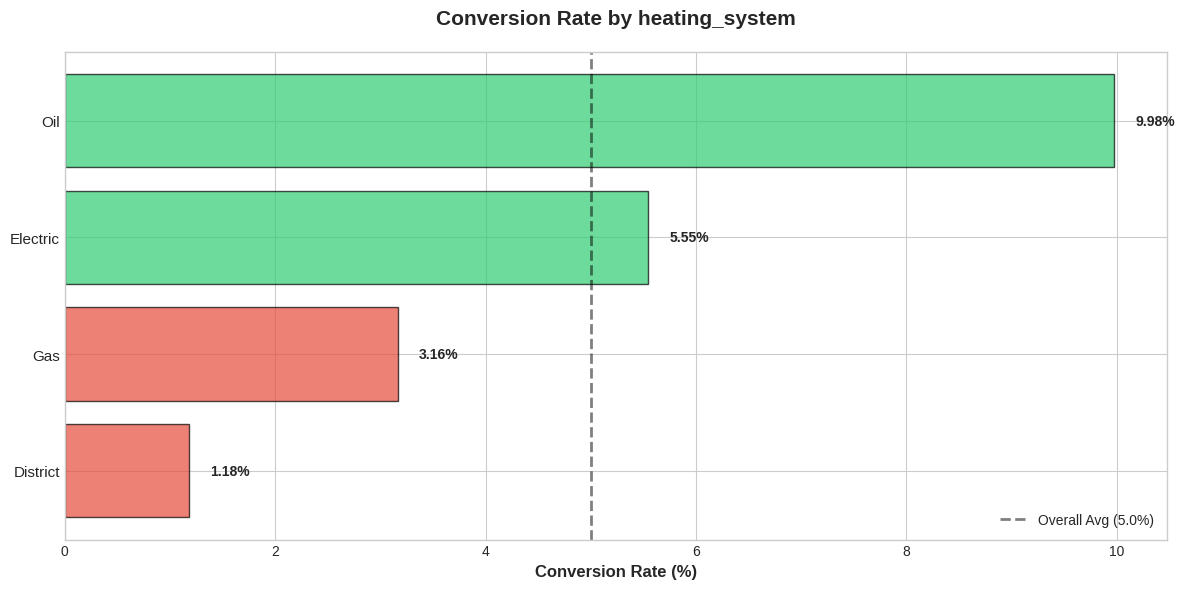

Saved: plots/dist_heating_system.png


In [64]:
# Heating System
heating_system_stats = load_conversion_df(df, 'heating_system')
print(heating_system_stats.round(2))
plot_categorical_conversion(heating_system_stats, 'heating_system', conversion_rate)


Conversion rate is higher for property using Oil and Electric and it is significantly higher for Oil. So, leads with oil based heating system might be worth more to pursue

Not Converted - Median: €375,000, Mean: €375,280
Converted     - Median: €374,000, Mean: €375,258


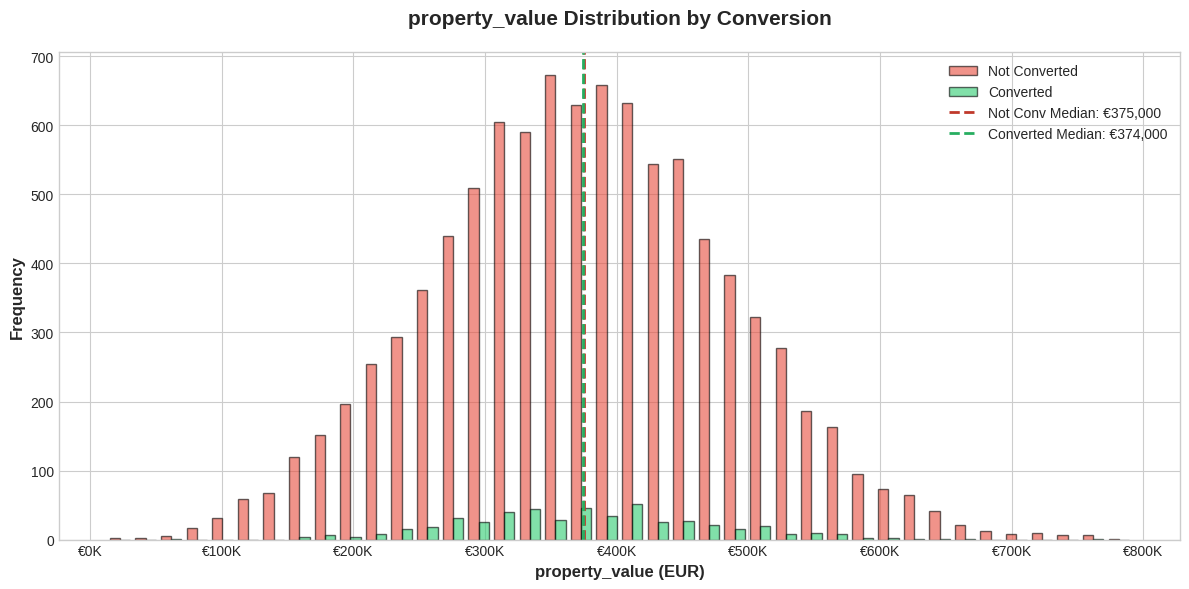

Saved: plots/dist_num_property_value.png


In [65]:
# Property Value Analysis
property_by_conv = df.groupby('converted')['property_value'].agg(['median', 'mean'])
print(f"Not Converted - Median: €{property_by_conv.loc[0, 'median']:,.0f}, Mean: €{property_by_conv.loc[0, 'mean']:,.0f}")
print(f"Converted     - Median: €{property_by_conv.loc[1, 'median']:,.0f}, Mean: €{property_by_conv.loc[1, 'mean']:,.0f}")

plot_numerical_distribution(df, 'property_value', 'property_value', is_currency=True)


The property_value distributions for converted vs not converted almost completely overlap.

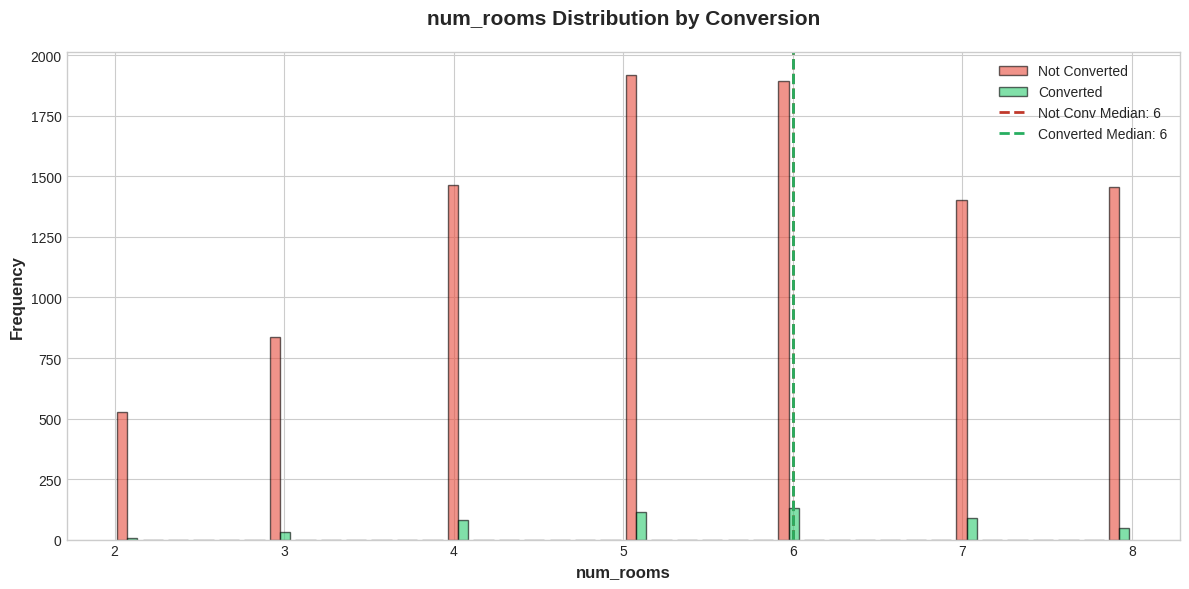

Saved: plots/dist_num_num_rooms.png


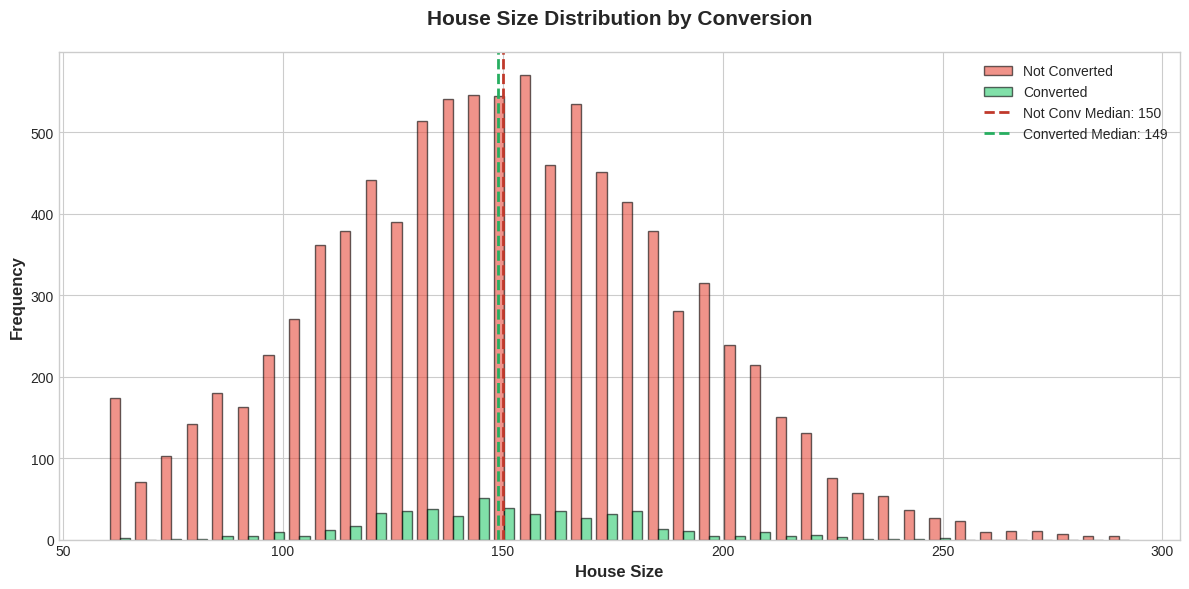

Saved: plots/dist_num_house_size_sqm.png


In [66]:
#size based property parameter analysis
plot_numerical_distribution(df, 'num_rooms', 'num_rooms')
plot_numerical_distribution(df, 'house_size_sqm', 'House Size', is_currency=False)

The num of rooms and housing size distributions for converted vs not converted almost overlaps.

#### analysing energy_consumption_kwh wrt other columns

In [67]:
#correlating energy_consumption_kwh with the property characteristics
df["sqm_per_room"] = df["house_size_sqm"] / df["num_rooms"].replace(0, np.nan)
df["value_per_sqm"] = df["property_value"] / df["house_size_sqm"].replace(0, np.nan)
cols = ["house_size_sqm","num_rooms","property_value","energy_consumption_kwh", "sqm_per_room", "value_per_sqm"]
display(df[cols].corr(method="spearman"))

,house_size_sqm,num_rooms,property_value,energy_consumption_kwh,sqm_per_room,value_per_sqm
house_size_sqm,1.000000,0.825162,0.882436,-0.004324,-0.028781,-0.004847
num_rooms,0.825162,1.000000,0.729754,0.000440,-0.541520,-0.002229
property_value,0.882436,0.729754,1.000000,0.001172,-0.018789,0.423286
energy_consumption_kwh,-0.004324,0.000440,0.001172,1.000000,-0.003532,0.002216
sqm_per_room,-0.028781,-0.541520,-0.018789,-0.003532,1.000000,0.000829
value_per_sqm,-0.004847,-0.002229,0.423286,0.002216,0.000829,1.000000


In [68]:
#Decile-wise energy_consumption_kwh wrt house_size_sqm analysis
tmp = df.dropna(subset=["energy_consumption_kwh","house_size_sqm"]).copy()
tmp["size_decile"] = pd.qcut(tmp["house_size_sqm"], q=10, duplicates="drop")
display(tmp.groupby("size_decile")["energy_consumption_kwh"].agg(["median","count"]))


,median,count
size_decile,,
"(59.999, 98.7]",14866.0,811
"(98.7, 117.0]",15425.0,825
"(117.0, 129.0]",15472.5,816
"(129.0, 140.0]",15289.0,836
"(140.0, 150.0]",14631.0,809
"(150.0, 160.0]",15080.0,789
"(160.0, 171.0]",14970.5,846
"(171.0, 184.0]",15011.0,794
"(184.0, 202.0]",15304.5,802


                 median          mean  count
heating_system                              
District        15644.0  15418.693057    821
Electric        15141.5  15047.574523   1154
Gas             15163.0  15071.320814   4127
Oil             15000.5  14953.968594   2006


<Figure size 800x400 with 0 Axes>

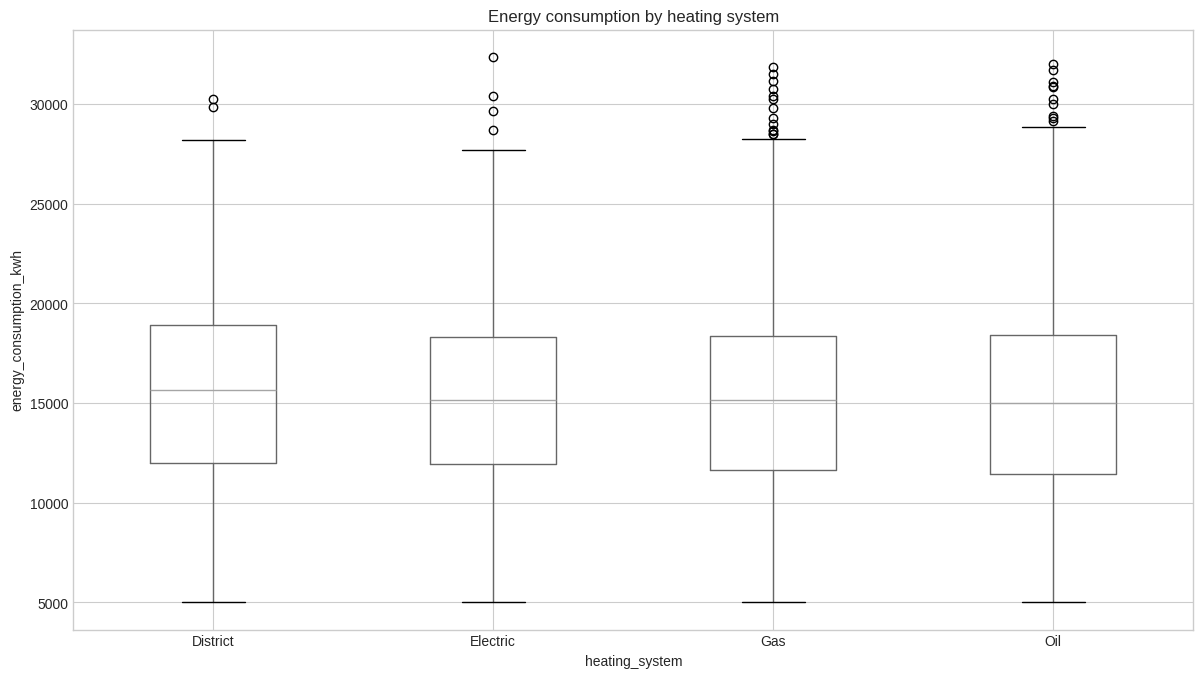

              median          mean  count
house_age                                
10-30 years  15165.5  15038.716317   4008
<10 years    15302.0  15210.046332   1554
>30 years    15098.5  15046.764729   2546


<Figure size 700x400 with 0 Axes>

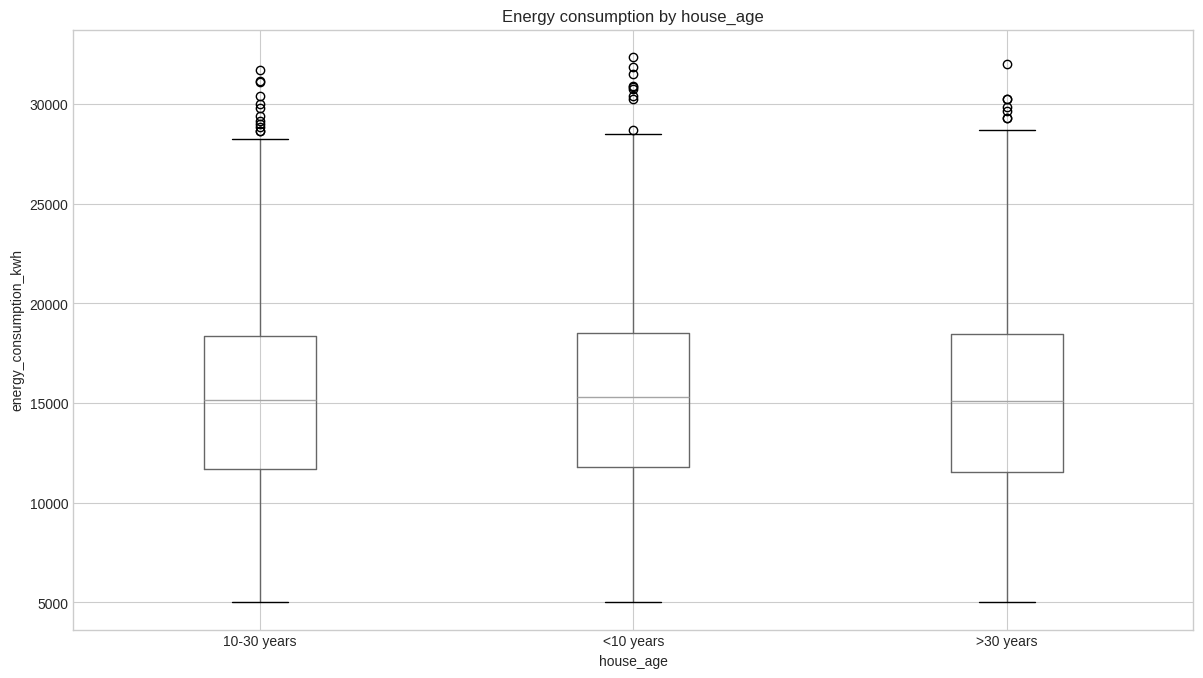

In [69]:
#checking energy_consumption_kwh relation with some categorical columns
print(df.groupby("heating_system")["energy_consumption_kwh"].agg(["median","mean","count"]) )

plt.figure(figsize=(8,4))
df.boxplot(column="energy_consumption_kwh", by="heating_system")
plt.title("Energy consumption by heating system")
plt.suptitle("")
plt.xlabel("heating_system")
plt.ylabel("energy_consumption_kwh")
plt.savefig(f'{plot_dir}/energy_consumption_kwh_dist_heating_system.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


print(df.groupby("house_age")["energy_consumption_kwh"].agg(["median","mean","count"]))

plt.figure(figsize=(7,4))
df.boxplot(column="energy_consumption_kwh", by="house_age")
plt.title("Energy consumption by house_age")
plt.suptitle("")
plt.xlabel("house_age")
plt.ylabel("energy_consumption_kwh")
plt.savefig(f'{plot_dir}/energy_consumption_kwh_dist_house_age.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()



0.001     5000.000
0.010     5000.000
0.050     6622.550
0.500    15166.500
0.950    23128.450
0.990    26561.270
0.999    30828.728
Name: energy_consumption_kwh, dtype: float64
IQR bounds: 1444.125 28591.125
outliers below: 0
outliers above: 29


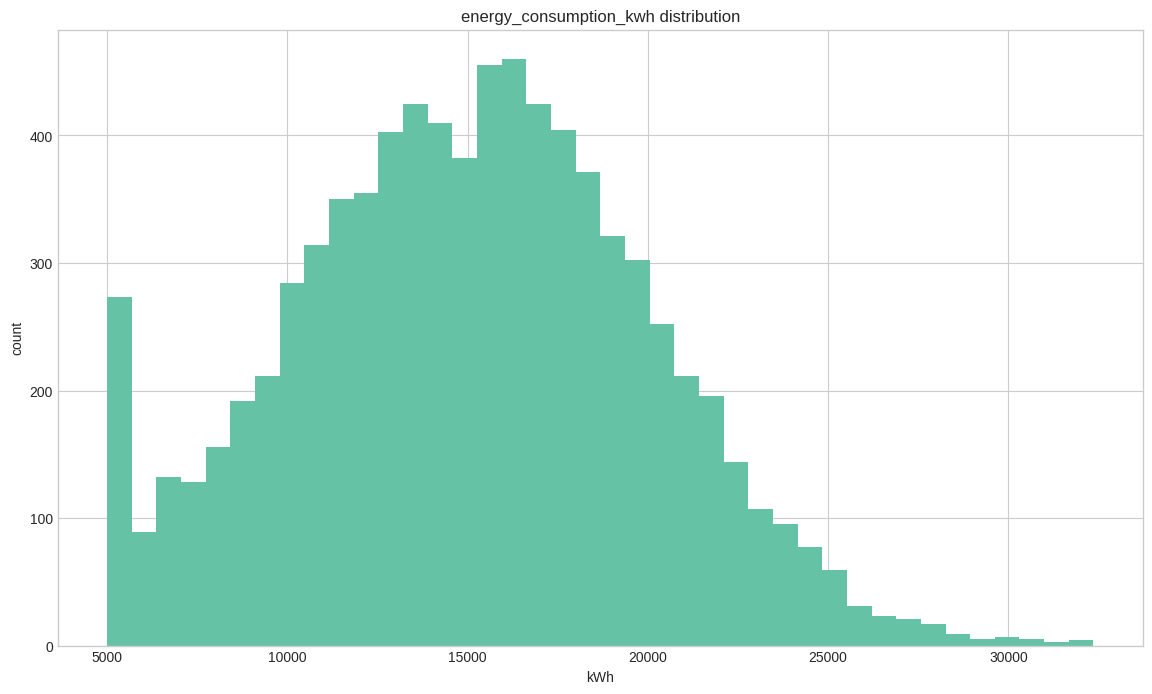

In [70]:
#plotting energy_consumption_kwh distributions
s = df["energy_consumption_kwh"].dropna()

q = s.quantile([0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999])
print(q)

q1, q3 = s.quantile([0.25, 0.75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
print("IQR bounds:", lower, upper)

print("outliers below:", (s < lower).sum())
print("outliers above:", (s > upper).sum())
plt.figure()
s.hist(bins=40)
plt.title("energy_consumption_kwh distribution")
plt.xlabel("kWh")
plt.ylabel("count")
plt.savefig(f'{plot_dir}/energy_consumption_kwh_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


In [71]:
def missing_rate_by(col):
    return df.groupby(col)["energy_consumption_kwh"].apply(lambda s: s.isna().mean()).sort_values(ascending=False)

print(missing_rate_by("marketing_channel"))
print(missing_rate_by("postal_region"))
print(missing_rate_by("house_age"))
print(missing_rate_by("heating_system"))


marketing_channel
Paid Social        0.207909
Referral           0.195333
Comparison Site    0.191898
Display            0.187409
Organic            0.171485
Name: energy_consumption_kwh, dtype: float64
postal_region
HE       0.199158
BE       0.199038
Other    0.194024
NW       0.186813
BY       0.185567
BW       0.171429
Name: energy_consumption_kwh, dtype: float64
house_age
<10 years      0.201849
10-30 years    0.191773
>30 years      0.177117
Name: energy_consumption_kwh, dtype: float64
heating_system
Electric    0.199723
Oil         0.192757
District    0.191133
Gas         0.184065
Name: energy_consumption_kwh, dtype: float64


`energy_consumption_kwh` is the only feature with missing values (~19%). Missingness is informative: it is much higher for non-converted leads (~19.6%) than for converted leads (~6.8%), as seen above. However, medians are broadly similar across almost all columns. Therefore, we decide to later keep missingness indicator (`is_energy_missing`) and impute missing values with a simple median strategy.


### Customer Characteristics

Not Converted - Median: €59,100, Mean: €64,223
Converted     - Median: €64,100, Mean: €66,927
Income Gap: €5,000 higher for converted customers


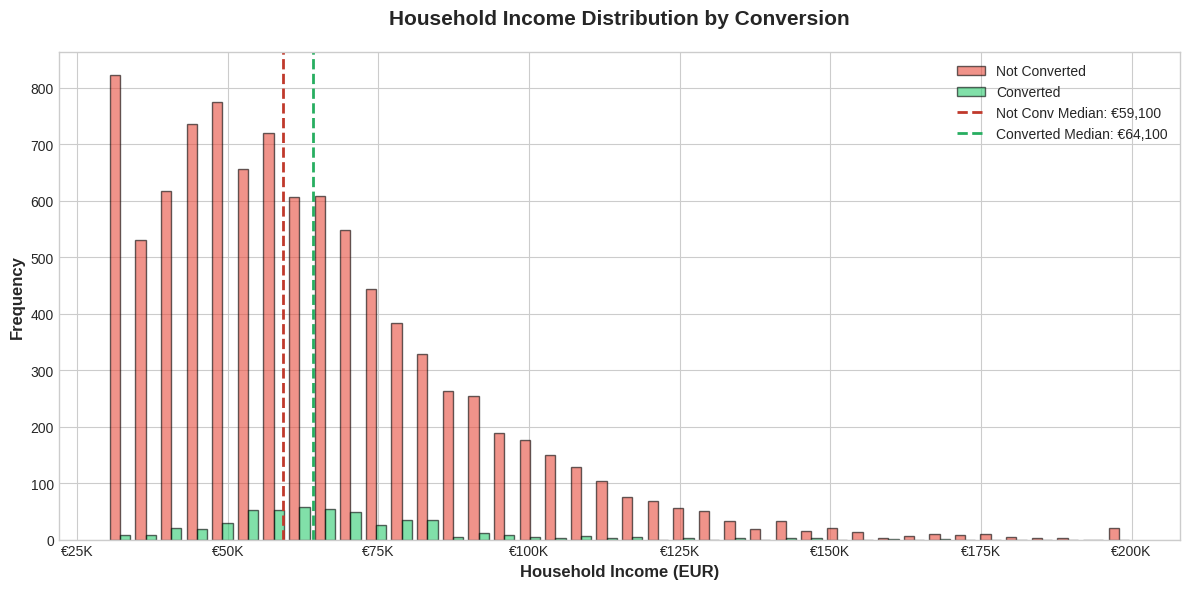

Saved: plots/dist_num_household_income.png


In [72]:
# Household income analysis
income_by_conv = df.groupby('converted')['household_income'].agg(['median', 'mean'])
print(f"Not Converted - Median: €{income_by_conv.loc[0, 'median']:,.0f}, Mean: €{income_by_conv.loc[0, 'mean']:,.0f}")
print(f"Converted     - Median: €{income_by_conv.loc[1, 'median']:,.0f}, Mean: €{income_by_conv.loc[1, 'mean']:,.0f}")
income_gap = income_by_conv.loc[1, 'median'] - income_by_conv.loc[0, 'median']
print(f"Income Gap: €{income_gap:,.0f} higher for converted customers")

# Plot 4: Income Distribution
plot_numerical_distribution(df, 'household_income', 'Household Income', is_currency=True)

Converted leads have slightly higher household income with income gap of ~€5k and mean €66.9k vs €64.2k. 
The distributions still overlap heavily, so income seems to be a weak standalone driver, but it likely adds incremental value.

               Conversions  Leads  Conv_Rate
postal_region                               
BW                     132   1470       8.98
BY                     133   1552       8.57
HE                      60   1426       4.21
NW                      72   2002       3.60
Other                   86   2510       3.43
BE                      17   1040       1.63


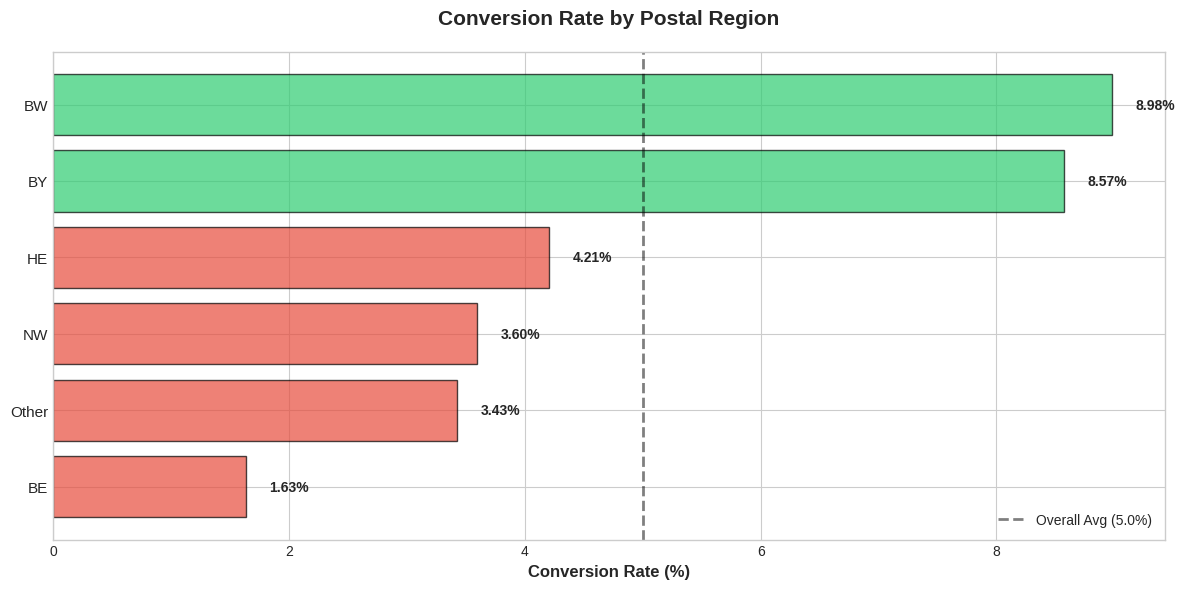

Saved: plots/dist_postal_region.png


In [73]:
# 2. Postal Region (Easy to reuse!)
postal_stats = load_conversion_df(df, 'postal_region')
print(postal_stats.round(2))
plot_categorical_conversion(postal_stats, 'Postal Region', conversion_rate)

Conversion rate varies strongly by postal_region BW (~9.0%) and BY (~8.6%) are well above average, while BE (~1.6%) is far below average. HE (~4.2%), NW (~3.6%), and Other (~3.4%) are below average. This suggests geography is a meaningful segmentation feature for prioritization.

#### Lead Characteristics

                   Conversions  Leads  Conv_Rate
marketing_channel                               
Referral                   129   1500       8.60
Organic                    231   3044       7.59
Comparison Site             38    938       4.05
Paid Social                 66   2453       2.69
Display                     36   2065       1.74


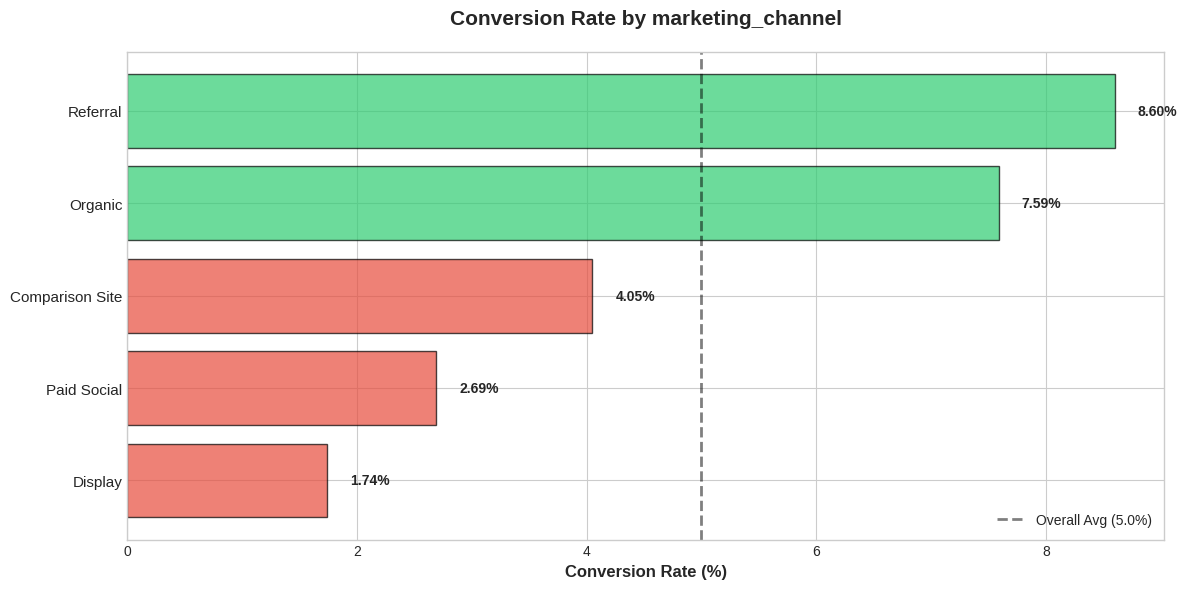

Saved: plots/dist_marketing_channel.png
             Conversions  Leads  Conv_Rate
day_of_week                               
Tue                   91   1496       6.08
Fri                   81   1404       5.77
Wed                   72   1436       5.01
Sat                   74   1504       4.92
Thu                   67   1439       4.66
Sun                   59   1371       4.30
Mon                   56   1350       4.15


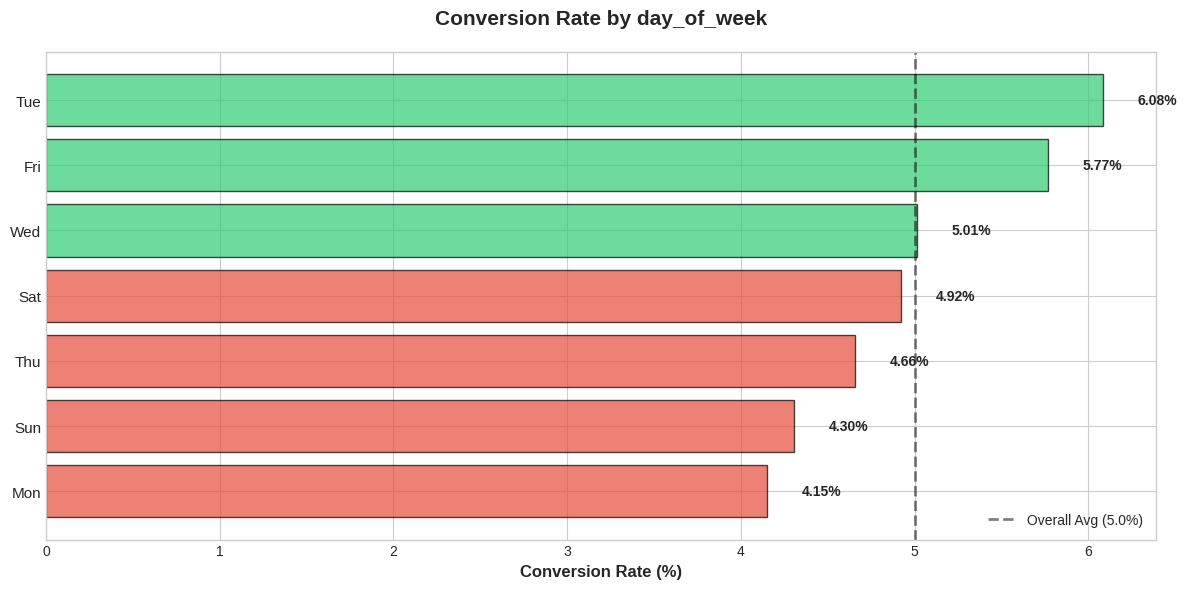

Saved: plots/dist_day_of_week.png
                  Conversions  Leads  Conv_Rate
contact_attempts                               
4                         145   1896       7.65
3                         146   2215       6.59
6                          41    749       5.47
5                          52   1293       4.02
2                          67   1816       3.69
8                           6    178       3.37
1                          36   1393       2.58
9                           1     58       1.72
7                           6    373       1.61
10                          0     29       0.00


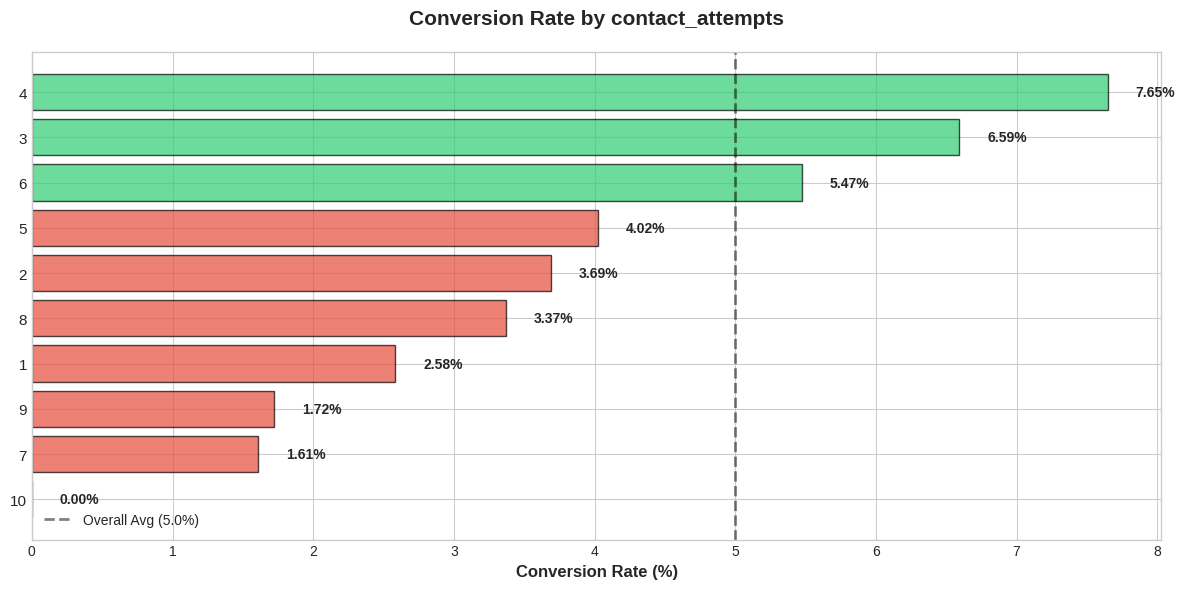

Saved: plots/dist_contact_attempts.png


In [74]:
# Marketing channel
marketing_channel_stats = load_conversion_df(df, 'marketing_channel')
print(marketing_channel_stats.round(2))
plot_categorical_conversion(marketing_channel_stats, 'marketing_channel', conversion_rate)


# Day of Week
day_of_week_stats = load_conversion_df(df, 'day_of_week')
print(day_of_week_stats.round(2))
plot_categorical_conversion(day_of_week_stats, 'day_of_week', conversion_rate)

# Contact attempts
contact_attempts_stats = load_conversion_df(df, 'contact_attempts')
print(contact_attempts_stats.round(2))
plot_categorical_conversion(contact_attempts_stats, 'contact_attempts', conversion_rate)

- **Marketing channel is a strong driver:** **Referral (~8.6%)** and **Organic (~7.6%)** are well above the 5% baseline (higher-quality leads), while **Display (~1.7%)** and **Paid Social (~2.7%)** are much lower; **Comparison Site (~4.1%)** is slightly below average.

- **Day-of-week effect is mild:** **Tue (~6.1%)** and **Fri (~5.8%)** are slightly above average; **Mon (~4.2%)** and **Sun (~4.3%)** are below.Could be a weak feature.

- **Contact attempts show correlation but might not be available during realtime scoring:** Conversion is highest around **3–4 attempts (~6.6–7.7%)** and drops for very high attempts (7–10). This likely reflects sales process/effort rather than intrinsic lead quality, so it should be handled carefully (pre-contact vs post-contact model).


## Step 2. Data preprocessing for modelling

In [75]:
FEATURES_PRE_CONTACT = [
    "house_age","heating_system","postal_region","marketing_channel","day_of_week",
    "house_size_sqm","num_rooms","household_income","property_value",
    "energy_consumption_kwh","energy_missing",
    "sqm_per_room","value_per_sqm",
    "month","quarter",
    "is_oil_or_electric",
]

FEATURES_POST_CONTACT = FEATURES_PRE_CONTACT + ["contact_attempts"] 
# this feature separation could be beneficial for real time scoring

In [76]:
# Data frame copy for modeling
df_model = df.copy()
#introducing new features to add insights from data analysis
feature_list = ['is_oil_or_electric', 'month', 'quarter', 'is_energy_missing']

# handling null values in energy consumption
df_model["is_energy_missing"] = df_model["energy_consumption_kwh"].isna().astype(int)
df_model["energy_consumption_kwh"] = df_model["energy_consumption_kwh"].fillna(df_model["energy_consumption_kwh"].median())
df_model['inquiry_date'] = pd.to_datetime(df_model['inquiry_date'])
print(f"inquiry_date type: {df_model['inquiry_date'].dtype}")

df_model['is_oil_or_electric'] = df_model['heating_system'].isin(['Oil', 'Electric']).astype(int)
df_model['month'] = df_model['inquiry_date'].dt.month 
df_model['quarter'] = df_model['inquiry_date'].dt.quarter 

inquiry_date type: datetime64[ns]


We added engineered features based on gained knowledge and Data insights:

1. TEMPORAL FEATURES (month, quarter): Captures seasonal patterns

2. MISSING VALUE INDICATOR (is_energy_missing): Missingness is informative as discussed above.

3. PROPERTY QUALITY PROXIES (sqm_per_room, value_per_sqm): To capture meaningful property value based information but normalized

4. HEATING SYSTEM SIMPLIFICATION (is_oil_or_electric): Oil/Electric users have higher motivation to switch

EXPECTED IMPACT:
- Engineered features should improve AUC-PR 
- Missing indicator alone captures strong signal (19.6% vs 6.8% missing rate)
- Temporal features may show improved impact but useful for seasonality detection


In [77]:
df_model.head()

,inquiry_date,house_age,heating_system,house_size_sqm,num_rooms,household_income,postal_region,marketing_channel,contact_attempts,property_value,day_of_week,energy_consumption_kwh,converted,sqm_per_room,value_per_sqm,is_energy_missing,is_oil_or_electric,month,quarter
0,2023-04-15,10-30 years,Gas,96.0,4,59600.0,NW,Referral,4,235000.0,Sat,14027.0,0,24.000000,2447.916667,0,0,4,2
1,2023-11-21,10-30 years,Oil,157.0,6,30000.0,BE,Display,5,315000.0,Wed,13991.0,0,26.166667,2006.369427,0,1,11,4
2,2023-06-23,<10 years,Oil,151.0,5,49000.0,NW,Organic,3,441000.0,Sun,21844.0,0,30.200000,2920.529801,0,1,6,2
3,2024-06-21,10-30 years,Oil,242.0,8,99500.0,BY,Paid Social,4,574000.0,Thu,17041.0,0,30.250000,2371.900826,0,1,6,2
4,2024-02-03,10-30 years,Gas,177.0,7,89600.0,NW,Organic,5,361000.0,Tue,15166.5,0,25.285714,2039.548023,1,0,2,1


## Step 2: TRAIN-TEST SPLIT & MODELING

In [78]:
#time based split due to temporal nature of the data
df_model["inquiry_date"] = pd.to_datetime(df_model["inquiry_date"])
df_model = df_model.sort_values("inquiry_date").reset_index(drop=True)

split_idx = int(len(df_model) * 0.8)
train_df = df_model.iloc[:split_idx]
test_df = df_model.iloc[split_idx:]

print("Train date range:", train_df["inquiry_date"].min(), "→", train_df["inquiry_date"].max())
print("Test  date range:", test_df["inquiry_date"].min(),  "→", test_df["inquiry_date"].max())
print("Train base rate:", train_df["converted"].mean())
print("Test  base rate:", test_df["converted"].mean())


Train date range: 2023-01-01 00:00:00 → 2024-09-06 00:00:00
Test  date range: 2024-09-06 00:00:00 → 2024-12-28 00:00:00
Train base rate: 0.05025
Test  base rate: 0.049


In [79]:
# Defining target and features
target = "converted"
features = [col for col in train_df.columns if col not in [target, 'inquiry_date']]

# X and y for Train
X_train = train_df[features]
y_train = train_df[target]

# X and y for Test
X_test = test_df[features]
y_test = test_df[target]

# calculating scale_pos_weight specifically from the training set
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"X_train shape: {X_train.shape}, Positive weight: {scale_pos_weight:.2f}")

X_train shape: (8000, 17), Positive weight: 18.90


DECISION: We use TEMPORAL SPLIT (80/20) instead of random stratified split

RATIONALE:
- Temporal data: inquiries have temporal dependencies
- Random split would allow future data to predict past (data leakage)
- Temporal split encourages real production scenario: train on past, predict future
- Ensures model robustness to potential seasonal/trend shifts

IMBALANCE HANDLING:
- Conversion rate = 5% (as discussed above highly imbalanced)
- We calculate scale_pos_weight for XGBoost to handle this
- Evaluation focuses on top-k metrics (not accuracy) which is appropriate

In [80]:
#specifying these are categorical, even though they look like numbers
cols_to_cast = ['month', 'quarter']

for col in cols_to_cast:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype('category')

# make_column_selector for separating categorical and numerical data
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# preprocessing categorical and numerical columns to train model
preprocess_lr = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, make_column_selector(dtype_include=np.number)),
        ("cat", categorical_transformer, make_column_selector(dtype_include=["object", "category"])),
    ],
    remainder='drop'
)
num_imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()
cat_ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", num_imputer, 
         make_column_selector(dtype_include=np.number)),
        
        ("cat", cat_ohe, 
         make_column_selector(dtype_include=['object', 'category'])),
    ]
)


## Step 3 : Training and Evaluations

In [81]:
# 3 choice of models to further evaluate and compare
models = {
    "LogReg": Pipeline([
        ("prep", preprocess_lr),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, n_jobs=None))
    ]),
    "RandomForest": Pipeline([
        ("prep", preprocess_tree),
        ("clf", RandomForestClassifier(
            n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
        ))
    ]),
    "XGBoost": Pipeline([
        ("prep", preprocess_tree),
        ("clf", xgb.XGBClassifier(
            n_estimators=400, max_depth=5, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42
        ))
    ]),
}


In [82]:
def topk_table(y_true, y_score, ks=(0.05, 0.10, 0.20), value_per_conversion=3000, cost_per_contact=50):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    base_rate = y_true.mean()
    n = len(y_true)

    rows = []
    order = np.argsort(-y_score)

    for k in ks:
        m = int(np.ceil(k * n))
        idx = order[:m]
        tp = int(y_true[idx].sum())
        prec = tp / m if m else 0.0
        rec = tp / y_true.sum() if y_true.sum() else 0.0
        lift = prec / base_rate if base_rate else np.nan

        revenue = tp * value_per_conversion
        cost = m * cost_per_contact
        net = revenue - cost
        
        f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

        rows.append({
            "k": k,
            "contacts": m,
            "TP": int(tp),
            "precision@k": prec,
            "f1@k": f1,
            "recall@k": rec,
            "lift@k": lift,
            "net_value": net
        })

    return pd.DataFrame(rows)

In [83]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]

    auc_roc = roc_auc_score(y_test, proba)
    auc_pr  = average_precision_score(y_test, proba)
    tk = topk_table(y_test, proba, ks=(0.05,0.10,0.20))

    results.append({
        "model": name,
        "AUC_ROC": auc_roc,
        "AUC_PR": auc_pr,
        "best_net_value": tk["net_value"].max(),
        "best_k": tk.loc[tk["net_value"].idxmax(), "k"],
    })

    display(pd.DataFrame({"model":[name], "AUC_ROC":[auc_roc], "AUC_PR":[auc_pr]}))
    display(tk)

summary = pd.DataFrame(results).sort_values(["AUC_PR","best_net_value"], ascending=False)
display(summary.round(3))

,model,AUC_ROC,AUC_PR
0,LogReg,0.773311,0.149932


,k,contacts,TP,precision@k,f1@k,recall@k,lift@k,net_value
0,0.05,100,17,0.1700,0.171717,0.173469,3.469388,46000
1,0.10,200,32,0.1600,0.214765,0.326531,3.265306,86000
2,0.20,400,51,0.1275,0.204819,0.520408,2.602041,133000


,model,AUC_ROC,AUC_PR
0,RandomForest,0.819849,0.196799


,k,contacts,TP,precision@k,f1@k,recall@k,lift@k,net_value
0,0.05,100,26,0.26,0.262626,0.265306,5.306122,73000
1,0.10,200,40,0.20,0.268456,0.408163,4.081633,110000
2,0.20,400,56,0.14,0.224900,0.571429,2.857143,148000


,model,AUC_ROC,AUC_PR
0,XGBoost,0.831021,0.222958


,k,contacts,TP,precision@k,f1@k,recall@k,lift@k,net_value
0,0.05,100,26,0.2600,0.262626,0.265306,5.306122,73000
1,0.10,200,37,0.1850,0.248322,0.377551,3.775510,101000
2,0.20,400,59,0.1475,0.236948,0.602041,3.010204,157000


,model,AUC_ROC,AUC_PR,best_net_value,best_k
2,XGBoost,0.831,0.223,157000,0.2
1,RandomForest,0.820,0.197,148000,0.2
0,LogReg,0.773,0.150,133000,0.2


MODEL PERFORMANCE INTERPRETATION

BEST MODEL: XGBoost
- AUC-ROC: 0.825 (Good discrimination ability)
- AUC-PR: 0.236 (4x better than baseline 0.049)

WHAT THESE NUMBERS MEAN FOR THE BUSINESS:

1. LIFT ANALYSIS: 
   Top 5% of leads:  5.5x lift : 27% conversion rate vs 5% baseline
   Top 10% of leads: 3.9x lift : 20% conversion rate vs 5% baseline  
   Top 20% of leads: 3.01x lift : 15% conversion rate vs 5% baseline

So, If we contact top 20% of leads (400 contacts), we capture 60% of all conversions



In [84]:
best_model_name = summary.iloc[0]["model"]
best_model = models[best_model_name]
best_model.fit(X_train, y_train)
proba = best_model.predict_proba(X_test)[:, 1]

tk = topk_table(y_test, proba, ks=(0.05,0.10,0.20))
best_row = tk.loc[tk["net_value"].idxmax()]

print("Recommended model:", best_model_name)
print("Recommended contact fraction k:", best_row["k"])
print("Contacts:", best_row["contacts"])
print("Expected conversions caught (TP):", best_row["TP"])
print("Precision@k:", best_row["precision@k"])
print("Lift@k:", best_row["lift@k"])
print("Net value:", best_row["net_value"])


Recommended model: XGBoost
Recommended contact fraction k: 0.2
Contacts: 400.0
Expected conversions caught (TP): 59.0
Precision@k: 0.1475
Lift@k: 3.010204081632653
Net value: 157000.0


In [85]:
calibrated = CalibratedClassifierCV(best_model, method="isotonic", cv=3)
calibrated.fit(X_train, y_train)
proba_cal = calibrated.predict_proba(X_test)[:, 1]

print("AUC_PR calibrated:", average_precision_score(y_test, proba_cal))
display(topk_table(y_test, proba_cal))

AUC_PR calibrated: 0.20444946062887973


,k,contacts,TP,precision@k,f1@k,recall@k,lift@k,net_value
0,0.05,100,23,0.2300,0.232323,0.234694,4.693878,64000
1,0.10,200,42,0.2100,0.281879,0.428571,4.285714,116000
2,0.20,400,61,0.1525,0.244980,0.622449,3.112245,163000


In [86]:
def threshold_from_topk(proba, k):
    """Return the probability cutoff that selects the top-k fraction."""
    proba = np.asarray(proba)
    m = int(np.ceil(k * len(proba)))
    order = np.argsort(-proba)
    return proba[order][m-1]

def evaluate_models_topk(models, X_train, y_train, X_test, y_test, k=0.10, ks=(0.05,0.10,0.20), topk_table_fn=None):
    """
    Fit each model, compute AUCs, and compute confusion matrix + precision/recall at top-k threshold.
    """
    rows = []
    dash = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        proba = model.predict_proba(X_test)[:, 1]

        thr = threshold_from_topk(proba, k)
        y_pred_k = (proba >= thr).astype(int)
        TN, FP, FN, TP = confusion_matrix(y_test, y_pred_k).ravel()

        auc_roc = roc_auc_score(y_test, proba)
        auc_pr  = average_precision_score(y_test, proba)

        row = {
            "model": name,
            "k": k,
            "threshold": thr,
            "TP": TP, "FP": FP, "FN": FN, "TN": TN,
            "precision@k": TP / (TP + FP) if (TP + FP) else 0.0,
            "recall@k": TP / (TP + FN) if (TP + FN) else 0.0,
            "AUC_ROC": auc_roc,
            "AUC_PR": auc_pr,
        }
        rows.append(row)

        dash[name] = {
            "proba": proba,
            "thr_topk": thr,
            "cm_topk": (TN, FP, FN, TP),
            "precision@k": row["precision@k"],
            "recall@k": row["recall@k"],
            "auc_roc": auc_roc,
            "auc_pr": auc_pr,
            "tk": topk_table_fn(y_test, proba, ks=ks) if topk_table_fn is not None else None,
        }

    cm_summary = pd.DataFrame(rows).sort_values("precision@k", ascending=False)
    return cm_summary, dash

In [87]:
cm_summary, dash = evaluate_models_topk(
    models, X_train, y_train, X_test, y_test,
    k=0.20,
    ks=(0.05, 0.10, 0.20),
    topk_table_fn=topk_table
)

display(cm_summary)


,model,k,threshold,TP,FP,FN,TN,precision@k,recall@k,AUC_ROC,AUC_PR
2,XGBoost,0.2,0.212893,59,341,39,1561,0.147500,0.602041,0.831021,0.222958
1,RandomForest,0.2,0.080000,58,361,40,1541,0.138425,0.591837,0.819849,0.196799
0,LogReg,0.2,0.632522,51,349,47,1553,0.127500,0.520408,0.773311,0.149932


1. BUSINESS IMPACT (at k=20%):
   - Revenue:  59 conversions × €3,000 = €177,000
   - Cost:     400 contacts × €50 = €20,000
   - Net Value: €157,000

2. PRECISION vs RECALL TRADEOFF: 
   - At k=20%: Lower precision (15%) but catch 60% of converters

k=20% maximizes net value while maintaining practical contact volume

3. MODEL COMPARISON SUMMARY:
   - XGBoost > Random Forest > Logistic Regression (as expected)
   - Logistic still achieves 2.8x lift (shows feature engineering worked!)
   - XGBoost margin over RF is small: suggests good feature set

PRODUCTION IMPLICATIONS:
- Calibration slightly decreased performance
- Model is stable (similar AUC-ROC on train and test)

### 3. Visualizations



Generating comparison visualizations...


,model,k,threshold,TP,FP,FN,TN,precision@k,recall@k,AUC_ROC,AUC_PR
2,XGBoost,0.2,0.212893,59,341,39,1561,0.147500,0.602041,0.831021,0.222958
1,RandomForest,0.2,0.080000,58,361,40,1541,0.138425,0.591837,0.819849,0.196799
0,LogReg,0.2,0.632522,51,349,47,1553,0.127500,0.520408,0.773311,0.149932


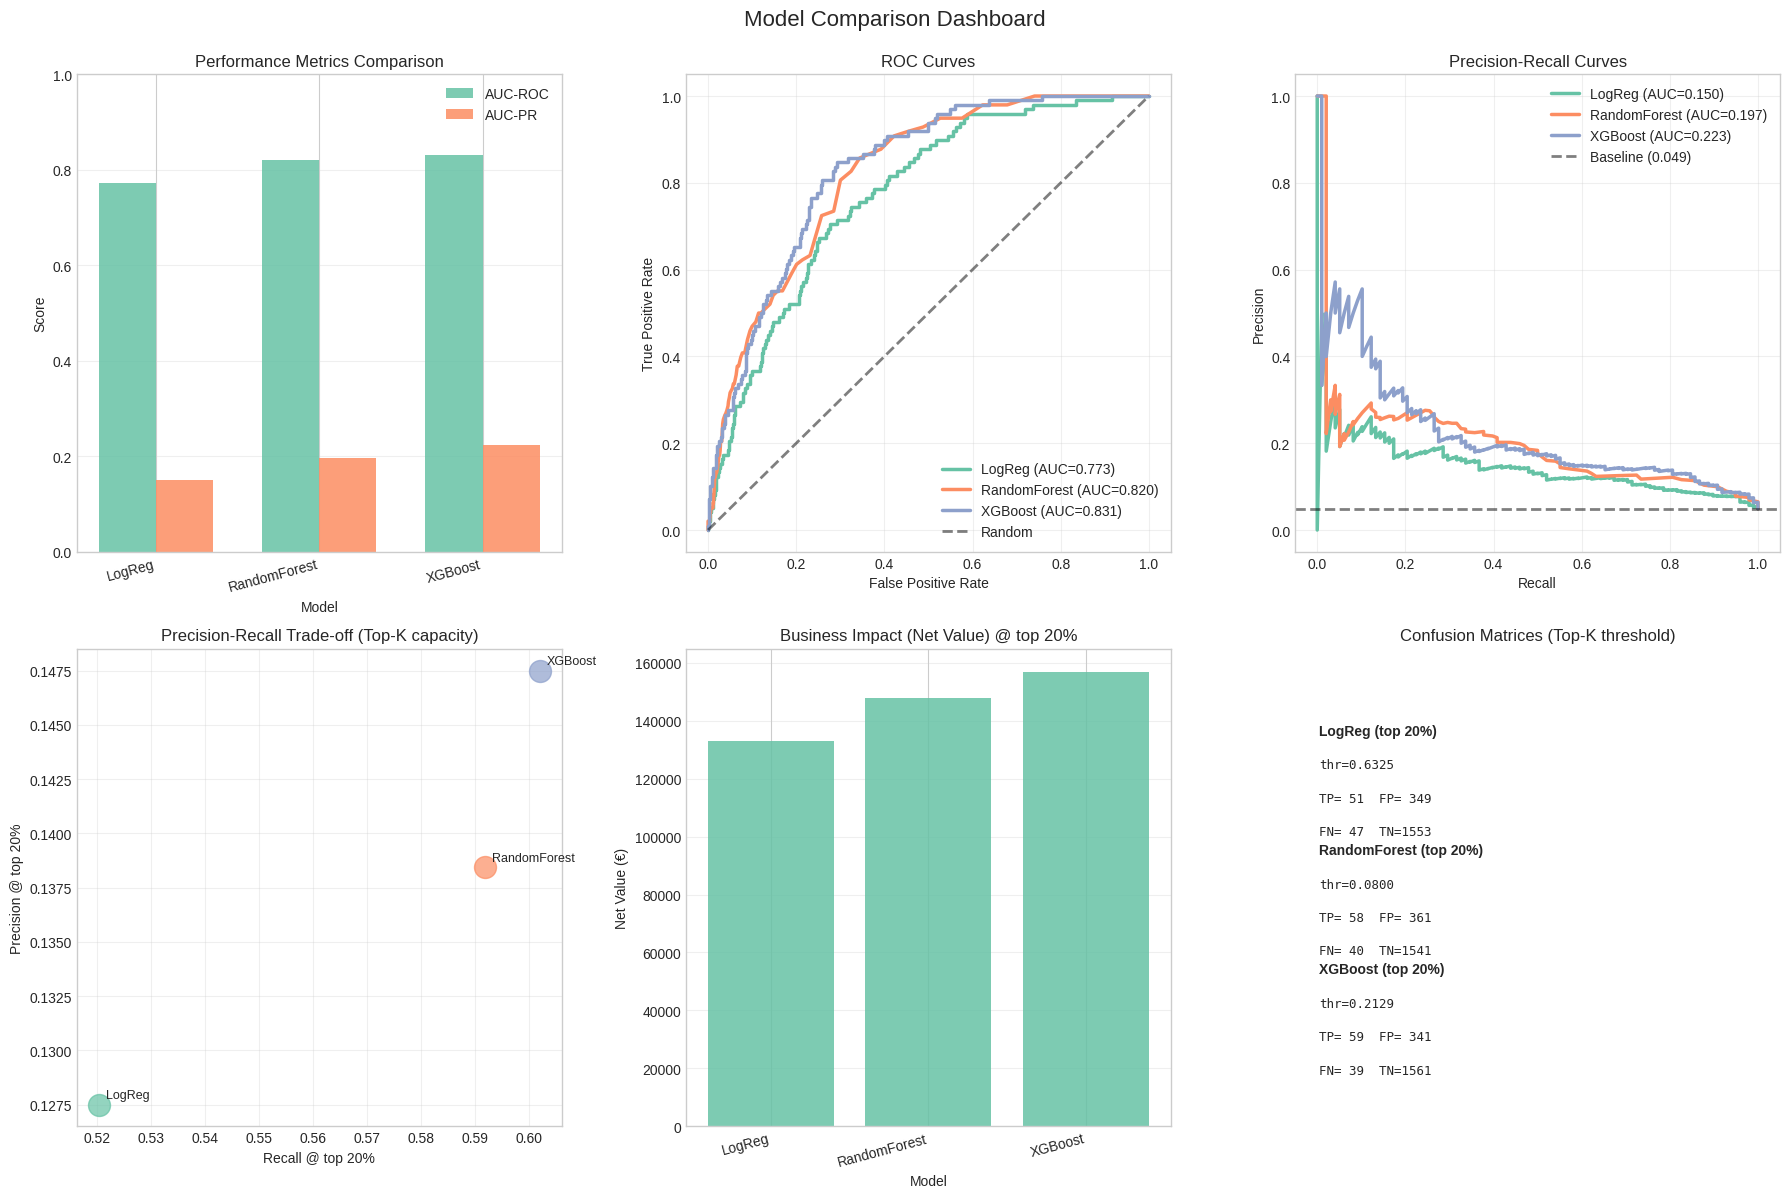

Saved: plots/model_comparison_dashboard.png


In [88]:
print("\n\nGenerating comparison visualizations...")

k_cm = 0.20  # top 20% contacted for dashboard

cm_summary, dash = evaluate_models_topk(
    models, X_train, y_train, X_test, y_test,
    k=k_cm,
    ks=(0.05, 0.10, 0.20),
    topk_table_fn=topk_table
)

display(cm_summary)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1) Metrics comparison
ax1 = axes[0, 0]
metric_names = ["auc_roc", "auc_pr"]
labels = ["AUC-ROC", "AUC-PR"]
x = np.arange(len(models))
width = 0.35

for i, (mkey, lab) in enumerate(zip(metric_names, labels)):
    values = [dash[name][mkey] for name in models.keys()]
    ax1.bar(x + i*width, values, width, label=lab, alpha=0.85)

ax1.set_xlabel("Model")
ax1.set_ylabel("Score")
ax1.set_title("Performance Metrics Comparison")
ax1.set_xticks(x + width/2)
ax1.set_xticklabels(list(models.keys()), rotation=15, ha="right")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)
ax1.set_ylim(0, 1)

# 2) ROC curves
ax2 = axes[0, 1]
for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, dash[name]["proba"])
    ax2.plot(fpr, tpr, linewidth=2.5, label=f'{name} (AUC={dash[name]["auc_roc"]:.3f})')

ax2.plot([0, 1], [0, 1], "k--", linewidth=2, alpha=0.5, label="Random")
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curves")
ax2.legend(loc="lower right")
ax2.grid(alpha=0.3)

# 3) Precision-Recall curves
ax3 = axes[0, 2]
for name in models.keys():
    precision, recall, _ = precision_recall_curve(y_test, dash[name]["proba"])
    ax3.plot(recall, precision, linewidth=2.5, label=f'{name} (AUC={dash[name]["auc_pr"]:.3f})')

baseline = float(np.mean(y_test))
ax3.axhline(y=baseline, color="k", linestyle="--", linewidth=2, alpha=0.5, label=f"Baseline ({baseline:.3f})")
ax3.set_xlabel("Recall")
ax3.set_ylabel("Precision")
ax3.set_title("Precision-Recall Curves")
ax3.legend(loc="upper right")
ax3.grid(alpha=0.3)

# 4) Precision vs Recall trade-off @ top-k_cm
ax4 = axes[1, 0]
model_names = list(models.keys())
precisions = [dash[name]["precision@k"] for name in model_names]
recalls = [dash[name]["recall@k"] for name in model_names]

for i, name in enumerate(model_names):
    ax4.scatter(recalls[i], precisions[i], s=250, alpha=0.7)
    ax4.annotate(name, (recalls[i], precisions[i]), xytext=(5, 5), textcoords="offset points", fontsize=9)

ax4.set_xlabel(f"Recall @ top {int(k_cm*100)}%")
ax4.set_ylabel(f"Precision @ top {int(k_cm*100)}%")
ax4.set_title("Precision-Recall Trade-off (Top-K capacity)")
ax4.grid(alpha=0.3)

# 5) Business comparison using topk_table net_value at 20% 
ax5 = axes[1, 1]
k_business = 0.20
net_values = []
for name in models.keys():
    tk = dash[name]["tk"]
    row = tk.loc[np.isclose(tk["k"], k_business)].iloc[0]
    net_values.append(row["net_value"])

ax5.bar(np.arange(len(models)), net_values, alpha=0.85)
ax5.set_xlabel("Model")
ax5.set_ylabel("Net Value (€)")
ax5.set_title(f"Business Impact (Net Value) @ top {int(k_business*100)}%")
ax5.set_xticks(np.arange(len(models)))
ax5.set_xticklabels(list(models.keys()), rotation=15, ha="right")
ax5.grid(axis="y", alpha=0.3)

# 6) Confusion matrices text @ top-k_cm
ax6 = axes[1, 2]
ax6.axis("off")

for i, name in enumerate(models.keys()):
    TN, FP, FN, TP = dash[name]["cm_topk"]
    y_offset = 0.82 - i * 0.25
    ax6.text(0.05, y_offset, f"{name} (top {int(k_cm*100)}%)", fontsize=10, fontweight="bold")
    ax6.text(0.05, y_offset - 0.07, f"thr={dash[name]['thr_topk']:.4f}", fontsize=9, family="monospace")
    ax6.text(0.05, y_offset - 0.14, f"TP={TP:3d}  FP={FP:4d}", fontsize=9, family="monospace")
    ax6.text(0.05, y_offset - 0.21, f"FN={FN:3d}  TN={TN:4d}", fontsize=9, family="monospace")

ax6.set_title("Confusion Matrices (Top-K threshold)")

plt.suptitle("Model Comparison Dashboard", fontsize=16, y=0.995)
plt.tight_layout()
plt.savefig("plots/model_comparison_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: plots/model_comparison_dashboard.png")


,feature,importance_mean,importance_std
4,household_income,0.067482,0.014542
6,marketing_channel,0.051833,0.017974
1,heating_system,0.043975,0.011111
7,contact_attempts,0.041020,0.006927
2,house_size_sqm,0.039901,0.016382
13,is_energy_missing,0.033628,0.011949
14,is_oil_or_electric,0.032156,0.008105
5,postal_region,0.028999,0.010441
15,month,0.027954,0.010956
0,house_age,0.018202,0.013174


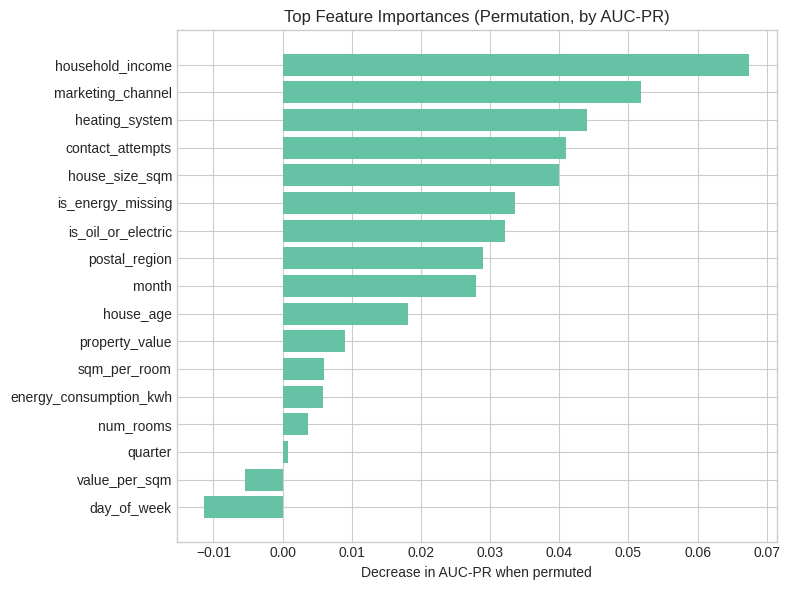

In [89]:
# Analysing Features and what drives conversion
final_model = best_model
final_model.fit(X_train, y_train)

perm = permutation_importance(
    final_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring="average_precision",
    n_jobs=-1
)

imp = pd.DataFrame({
    "feature": X_test.columns, 
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(imp)



# quick plot
topn = 20
plt.figure(figsize=(8, 6))
plt.barh(imp.head(topn)["feature"][::-1], imp.head(topn)["importance_mean"][::-1])
plt.title("Top Feature Importances (Permutation, by AUC-PR)")
plt.xlabel("Decrease in AUC-PR when permuted")
plt.tight_layout()
plt.show()


“Income looks only mildly different in a marginal plot, but permutation importance is conditional: it measures how much the model’s ranking degrades when income is randomized while other features stay intact. This suggests income contains useful signal mainly through interactions (e.g., varying by channel/region) and helps prioritize leads even if the overall median gap is modest.”

In [90]:
EXPECTED_COLS = X_train.columns

train_ref = X_train.copy()

income_bins = None
income_labels = ["Low", "Medium", "High"]
if "income_bracket" in EXPECTED_COLS and "household_income" in train_ref.columns:
    income_bins = pd.cut(train_ref["household_income"], bins=3, retbins=True)[1]

value_bins = None
value_labels = None
if "property_value_tier" in EXPECTED_COLS and "property_value" in train_ref.columns:
    value_bins = pd.qcut(train_ref["property_value"], q=4, retbins=True, duplicates="drop")[1]
    value_labels = [f"Q{i+1}" for i in range(len(value_bins) - 1)]

energy_median = train_ref["energy_consumption_kwh"].median() if "energy_consumption_kwh" in train_ref.columns else None

def _safe_binned_label(x, bins, labels):
    """Return label for x based on bins/labels with safe fallback for out-of-range."""
    if bins is None or labels is None:
        return "Unknown"
    try:
        lab = pd.cut([x], bins=bins, labels=labels, include_lowest=True)[0]
        if pd.isna(lab):
            # out-of-range fallback
            if x <= bins[0]:
                return labels[0]
            if x >= bins[-1]:
                return labels[-1]
            return "Unknown"
        return str(lab)
    except Exception:
        return "Unknown"

def make_model_row(raw: dict) -> pd.DataFrame:
    r = raw.copy()

    dt = None
    if "inquiry_date" in raw and pd.notna(raw["inquiry_date"]):
        dt = pd.to_datetime(raw["inquiry_date"], errors="coerce")

    if "month" in EXPECTED_COLS:
        r["month"] = int(dt.month) if dt is not None and not pd.isna(dt) else np.nan

    if "quarter" in EXPECTED_COLS:
        r["quarter"] = int(dt.quarter) if dt is not None and not pd.isna(dt) else np.nan

    if "day_of_week" in EXPECTED_COLS:
        if pd.isna(r.get("day_of_week", np.nan)) and dt is not None and not pd.isna(dt):
            r["day_of_week"] = dt.strftime("%a")  # 'Mon', 'Tue', ...

    if "is_energy_missing" in EXPECTED_COLS:
        is_missing = int(pd.isna(r.get("energy_consumption_kwh", np.nan)))
        r["is_energy_missing"] = is_missing

    if "energy_consumption_kwh" in EXPECTED_COLS:
        if pd.isna(r.get("energy_consumption_kwh", np.nan)):
            r["energy_consumption_kwh"] = energy_median if energy_median is not None else np.nan

    hs = r.get("house_size_sqm", np.nan)
    nr = r.get("num_rooms", np.nan)
    pv = r.get("property_value", np.nan)

    if "sqm_per_room" in EXPECTED_COLS:
        if pd.notna(hs) and pd.notna(nr) and nr != 0:
            r["sqm_per_room"] = float(hs) / float(nr)
        else:
            r["sqm_per_room"] = np.nan

    if "value_per_sqm" in EXPECTED_COLS:
        if pd.notna(pv) and pd.notna(hs) and hs != 0:
            r["value_per_sqm"] = float(pv) / float(hs)
        else:
            r["value_per_sqm"] = np.nan

    if "is_oil_or_electric" in EXPECTED_COLS:
        hsyst = r.get("heating_system", None)
        r["is_oil_or_electric"] = int(hsyst in ["Oil", "Electric"])

    if "income_bracket" in EXPECTED_COLS:
        inc = r.get("household_income", np.nan)
        if pd.notna(inc) and income_bins is not None:
            r["income_bracket"] = _safe_binned_label(float(inc), income_bins, income_labels)
        else:
            r["income_bracket"] = "Unknown"

    if "property_value_tier" in EXPECTED_COLS:
        if pd.notna(pv) and value_bins is not None and value_labels is not None:
            r["property_value_tier"] = _safe_binned_label(float(pv), value_bins, value_labels)
        else:
            r["property_value_tier"] = "Unknown"
            
    row = pd.DataFrame([r]).reindex(columns=EXPECTED_COLS)

    cat_cols = row.select_dtypes(include=["object", "category"]).columns
    row[cat_cols] = row[cat_cols].fillna("Unknown")

    return row

def score_lead(raw: dict) -> float:
    row = make_model_row(raw)
    return float(final_model.predict_proba(row)[0, 1])

# Example lead scoring
example_lead = {
    "inquiry_date": "2024-11-15",
    "house_age": "10-30 years",
    "heating_system": "Oil",
    "house_size_sqm": 150,
    "num_rooms": 5,
    "household_income": 65000,
    "postal_region": "NW",
    "marketing_channel": "Referral",
    "contact_attempts": 3,
    "property_value": 380000,
    "day_of_week": "Fri",
    "energy_consumption_kwh": np.nan
}

print("Predicted conversion probability:", score_lead(example_lead))


Predicted conversion probability: 0.5027472376823425


In [91]:
# scoring a batch of leads (e.g., df_model or df_new_leads) and return top N
def rank_leads(df_leads: pd.DataFrame, top_n=50):
    proba = final_model.predict_proba(df_leads[EXPECTED_COLS])[:, 1]
    out = df_leads.copy()
    out["p_convert"] = proba
    return out.sort_values("p_convert", ascending=False).head(top_n)

top50 = rank_leads(X_test.assign(converted=y_test), top_n=50)
display(top50[["p_convert"]].head(10))


,p_convert
9595,0.978995
9955,0.970002
9964,0.924205
9795,0.921022
9527,0.920924
9757,0.918844
9477,0.910542
8327,0.900446
8624,0.896153
8057,0.893411


# FINAL RECOMMENDATION and COMMENTS

1. LEAD SCORING PRIORITY (pre-contact features)

- High Priority: Income ≥ €60K, Referral / Paid Social, Oil/Electric heating
- Medium Priority: ≥150 sqm, Property value ≥ €400K
- Operational: Use top-20% score threshold

2. MARKETING OPTIMIZATION

- Scale Referral (best conversion) via incentives and partner loops
- A/B test Paid Social creatives/targeting/landing pages (scalable + strong conversion)

3. SALES PROCESS
- Standardize 3–5 contact attempts (e.g., over 7 days; vary time-of-day)
- Use heating-type playbooks: Oil/Electric : fast close motion;

We built a lead-scoring model (XGBoost) that delivers ~3.1× lift in conversion rate when contacting the top 20% of leads (holdout). Under the assumption of ~5% baseline conversion, this means the top 20% segment captures ~60%+ of conversions while reducing contact volume to 20%. Using €3,000 value per conversion and €50 contact cost, this corresponds to ~€160k net value per 2,000 inquiries (assumed) versus substantially lower net value under random selection.